# Financial Lifecycle Trajectory

The previous notebook (`recommendation_system.ipynb`) answered: *which product today?*
This notebook answers: *when should that product change, and to what?*

## Methodological note — pseudo-panel construction

The dataset is **cross-sectional**: every client is observed once.
We cannot follow a single individual over decades.

The workaround is to treat clients within the same behavioural cluster as a synthetic cohort:
a 60-year-old with a conservative risk profile is a reasonable proxy for what a 40-year-old
with the same profile will look like in 20 years.
This is the **age-period-cohort** technique used in economics and epidemiology.

**Key assumptions (state as limitations)**:
1. Generational stationarity — macro conditions are stable across cohorts.
2. Cluster stability — relative behavioural profile stays constant as age changes within a cluster.
3. Model generalisation — XGBoost trained on real clients generalises to synthetic waypoints.

**Pipeline**:
0. Filter to clients the product catalog can serve **today** (t=0 serviceability check)
1. Cluster serviceable clients by behavioural profile (Age included at half weight)
2. Build an age ladder inside each cluster (5-year bands → representative waypoint)
3. Predict the optimal product at each waypoint using the XGBoost models already trained
4. Identify transition ages where the recommended product changes
5. Visualise the full trajectory

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path().resolve()))

from utils.preprocessing import (
    TARGETS,
    build_baseline_features,
    build_features,
    load_data,
    load_result,
)

# ── Data ──────────────────────────────────────────────────────────────────────
df = load_data()
products_df = pd.read_excel(Path('Data') / 'Dataset2_Needs.xls', sheet_name='Products')

prod_ids    = products_df['IDProduct'].values
prod_risks  = products_df['Risk'].values
income_mask = products_df['Type'].values == 0
accum_mask  = products_df['Type'].values == 1

print(f'Dataset : {df.shape[0]} clients, {df.shape[1]} columns')
print(f'Products: {len(products_df)}')
products_df

Dataset : 5000 clients, 9 columns
Products: 11


,IDProduct,Type,Risk
0,1,1,0.55
1,2,0,0.30
2,3,0,0.12
3,4,0,0.44
4,5,1,0.41
5,6,1,0.36
6,7,1,0.75
7,8,1,0.48
8,9,1,0.27
9,10,0,0.13


In [2]:
# ── Load pre-trained XGBoost models ───────────────────────────────────────────
# No retraining — we reuse the pickles from bestmodel_*.ipynb.

results = {}
for target in TARGETS:
    r = load_result('xgboost_shap', target)
    results[target] = r
    print(f'{target:30s}  features: {r["feature_names"]}')

IncomeInvestment                features: ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income_log', 'Wealth_log']
AccumulationInvestment          features: ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income_log', 'Wealth_log']


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────

# Pre-compute wealth-log range once (needed for RiskTarget normalisation)
_wealth_log = np.log1p(df['Wealth'])
_WL_MIN, _WL_MAX = float(_wealth_log.min()), float(_wealth_log.max())


def compute_risk_target(age, risk_propensity, financial_education, wealth):
    """Lifecycle-weighted risk target (same formula as recommendation_system.ipynb)."""
    wl = np.log1p(wealth)
    wn = np.clip((wl - _WL_MIN) / (_WL_MAX - _WL_MIN), 0.0, 1.0)
    rt = (
        0.50 * risk_propensity
        + 0.20 * financial_education
        - 0.20 * (age / 100)
        + 0.10 * wn
    )
    return float(np.clip(rt, 0.0, 1.0))


def personalized_match(risk_target, client_risk, product_risks, product_ids, type_mask):
    """Closest-to-target product, subject to MiFID hard ceiling."""
    mifid = type_mask & (product_risks <= client_risk)
    cand_r = product_risks[mifid]
    cand_i = product_ids[mifid]
    if len(cand_r) == 0:
        return 0, 0.0
    idx = np.argmin(np.abs(cand_r - risk_target))
    return int(cand_i[idx]), float(cand_r[idx])


def predict_need(profile_dict, result):
    """
    Predict P(positive) for a single client profile dict.
    Automatically selects F_E vs F_B based on the stored feature_names.
    XGBoost is scale-invariant; scaler is applied for correctness.
    """
    row_df = pd.DataFrame([profile_dict])
    feature_names = result['feature_names']
    model  = result['model']
    scaler = result.get('scaler')

    X_E = build_features(row_df)
    X_B = build_baseline_features(row_df)

    if all(f in X_E.columns for f in feature_names):
        X_feat = X_E[feature_names]
    else:
        X_feat = X_B[feature_names]

    X_arr = scaler.transform(X_feat) if scaler is not None else X_feat.values
    return float(model.predict_proba(X_arr)[0, 1])


print('Helpers defined.')

Helpers defined.


In [4]:
# ── t=0 serviceability filter ─────────────────────────────────────────────────
# A client is "serviceable" if the catalog can match them to a valid product
# at their actual current age and profile.
# Lifecycle analysis is restricted to this population: no trajectories for
# clients we cannot advise even today.

RAW_COLS = ['Age', 'Income', 'Wealth', 'RiskPropensity',
            'FinancialEducation', 'FamilyMembers', 'Gender']


def is_serviceable(row):
    profile  = row[RAW_COLS].to_dict()
    p_income = predict_need(profile, results['IncomeInvestment'])
    p_accum  = predict_need(profile, results['AccumulationInvestment'])
    dominant = 'Income' if p_income > p_accum else 'Accumulation'
    t_mask   = income_mask if dominant == 'Income' else accum_mask
    risk_target = compute_risk_target(
        row['Age'], row['RiskPropensity'],
        row['FinancialEducation'], row['Wealth'],
    )
    prod_id, _ = personalized_match(
        risk_target, row['RiskPropensity'],
        prod_risks, prod_ids, t_mask,
    )
    return prod_id > 0


df['serviceable'] = df.apply(is_serviceable, axis=1)

n_total       = len(df)
n_serviceable = int(df['serviceable'].sum())
pct           = n_serviceable / n_total * 100

print(f'Clients serviceable at t=0 : {n_serviceable} / {n_total} ({pct:.1f}%)')
print(f'Clients outside catalog    : {n_total - n_serviceable} ({100 - pct:.1f}%)')
print(f'\nLifecycle analysis is provided for the {pct:.1f}% of clients')
print(f'who can be matched to a product today.')

# All downstream analysis uses only serviceable clients
df_served = df[df['serviceable']].copy()

Clients serviceable at t=0 : 3921 / 5000 (78.4%)
Clients outside catalog    : 1079 (21.6%)

Lifecycle analysis is provided for the 78.4% of clients
who can be matched to a product today.


## Step 1 — Behavioural clustering

We cluster the **serviceable client population** on behavioural and financial dimensions.
**Age is included but at half weight** — this avoids two failure modes:
- *Zero weight*: clusters ignore lifecycle stage entirely, so the age ladder within each cluster
  may span the full range but with no variation in profile → flat, uninformative trajectories.
- *Full weight*: clusters become essentially age-ordered bands,
  losing the behavioural signal that makes each persona distinctive.

At half weight, Age nudges clusters toward life stages without overriding
`RiskPropensity` and `FinancialEducation` as primary discriminants.

| Feature | Rationale |
|---|---|
| `Age` (× 0.5) | Partial lifecycle anchoring — half weight |
| `RiskPropensity` | Primary MiFID signal — defines investor type |
| `FinancialEducation` | Sophistication level |
| `Wealth_log` | Patrimony stock (log to compress extreme values) |
| `Income_log` | Income flow |
| `Income_per_FM_log` | Per-capita savings capacity |
| `FamilyMembers` | Household structure |

**Cluster count selection** uses two complementary criteria:
- **Silhouette score** — measures how well each point fits its own cluster vs the nearest neighbour cluster (higher = better defined clusters)
- **Elbow / Inertia** — within-cluster sum of squares; look for the point where adding another cluster yields diminishing returns

**Minimum K = 4** — with fewer clusters the age ladder within each cluster spans too wide
a range without meaningful profile variation, producing flat and uninformative trajectories.

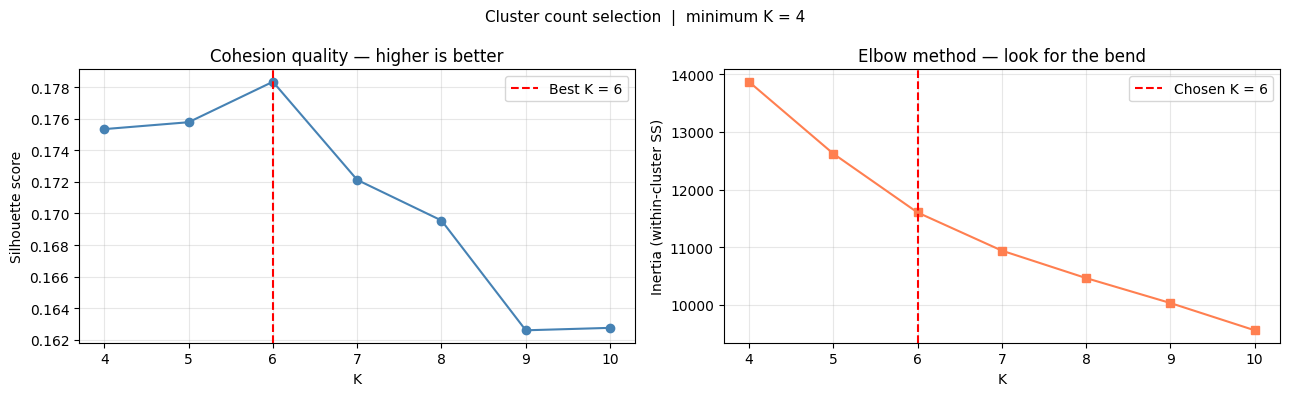

Selected K = 6  (silhouette = 0.1783, inertia = 11603.3)


In [5]:
# ── Clustering feature matrix (serviceable clients only) ──────────────────────
CLUSTER_FEATURES = [
    'Age',
    'RiskPropensity',
    'FinancialEducation',
    'Wealth_log',
    'Income_log',
    'Income_per_FM_log',
    'FamilyMembers',
]
AGE_WEIGHT = 0.5  # Age at half weight — lifecycle anchoring without dominating

X_all = build_features(df_served).copy()
X_all['FamilyMembers'] = df_served['FamilyMembers'].values

X_clust_raw = X_all[CLUSTER_FEATURES].values
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(X_clust_raw)

# Apply half weight to Age (first column)
age_col_idx = CLUSTER_FEATURES.index('Age')
X_clust[:, age_col_idx] *= AGE_WEIGHT

# ── Silhouette + Elbow sweep — K = 4 … 10 (minimum K = 4) ────────────────────
MIN_K = 4

sil_scores = {}
inertias   = {}

for k in range(MIN_K, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_clust)
    sil_scores[k] = silhouette_score(X_clust, labels)
    inertias[k]   = km.inertia_

# Best K by silhouette — already >= MIN_K by construction
best_k = max(sil_scores, key=sil_scores.get)

Ks = list(sil_scores.keys())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Silhouette
ax1.plot(Ks, [sil_scores[k] for k in Ks], 'o-', color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax1.set_xlabel('K')
ax1.set_ylabel('Silhouette score')
ax1.set_title('Cohesion quality — higher is better')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Elbow
ax2.plot(Ks, [inertias[k] for k in Ks], 's-', color='coral')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Chosen K = {best_k}')
ax2.set_xlabel('K')
ax2.set_ylabel('Inertia (within-cluster SS)')
ax2.set_title('Elbow method — look for the bend')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(f'Cluster count selection  |  minimum K = {MIN_K}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Selected K = {best_k}  '
      f'(silhouette = {sil_scores[best_k]:.4f}, '
      f'inertia = {inertias[best_k]:.1f})')

In [6]:
# ── Fit final clustering ──────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_labels = km_final.fit_predict(X_clust)
df_served['cluster'] = cluster_labels

# ── Find persona = real client nearest to each centroid ───────────────────────
from sklearn.metrics import pairwise_distances

centroids = km_final.cluster_centers_
medoid_idx = {}
for c in range(best_k):
    mask_c = cluster_labels == c
    dists  = pairwise_distances(X_clust[mask_c], centroids[[c]]).ravel()
    local_best = np.argmin(dists)
    medoid_idx[c] = df_served.index[mask_c][local_best]

print('Cluster sizes (serviceable clients only):')
for c in range(best_k):
    n   = (cluster_labels == c).sum()
    m   = medoid_idx[c]
    row = df_served.loc[m]
    print(f'  Cluster {c}: {n:4d} clients  '
          f'| Medoid — Age {row.Age:.0f}, '
          f'Risk {row.RiskPropensity:.2f}, '
          f'FinEdu {row.FinancialEducation:.2f}, '
          f'Wealth \u20ac{row.Wealth:.0f}k, '
          f'Income \u20ac{row.Income:.0f}k')

Cluster sizes (serviceable clients only):
  Cluster 0:  552 clients  | Medoid — Age 48, Risk 0.54, FinEdu 0.52, Wealth €45k, Income €26k
  Cluster 1:  890 clients  | Medoid — Age 59, Risk 0.33, FinEdu 0.37, Wealth €93k, Income €66k
  Cluster 2:  600 clients  | Medoid — Age 60, Risk 0.51, FinEdu 0.58, Wealth €164k, Income €94k
  Cluster 3:  483 clients  | Medoid — Age 47, Risk 0.32, FinEdu 0.32, Wealth €24k, Income €16k
  Cluster 4:  590 clients  | Medoid — Age 57, Risk 0.51, FinEdu 0.58, Wealth €123k, Income €102k
  Cluster 5:  806 clients  | Medoid — Age 55, Risk 0.31, FinEdu 0.37, Wealth €56k, Income €52k


In [7]:
# ── Persona cards ─────────────────────────────────────────────────────────────
# Assign persona names AFTER inspecting cluster profiles above.
# Update the override block manually based on the medoid profiles printed in Cell 7.
PERSONA_NAMES = {c: f'Persona {c}' for c in range(best_k)}

# --- MANUALLY OVERRIDE after reading cluster output above ---
# Example (update based on your actual cluster profiles):
# PERSONA_NAMES = {
#     0: 'The High-Earning Professional',
#     1: 'The Affluent Investor',
#     2: 'The Prudent Saver',
#     3: 'The Balanced Conservative',
# }

print('=' * 60)
for c in range(best_k):
    m    = medoid_idx[c]
    row  = df_served.loc[m]
    n    = (cluster_labels == c).sum()
    pct  = n / len(df_served) * 100
    name = PERSONA_NAMES.get(c, f'Persona {c}')
    print(f'{name.upper()}')
    print(f'  Clients         : {n} ({pct:.1f}%)')
    print(f'  Age             : {row.Age:.0f}')
    print(f'  Wealth          : €{row.Wealth:.0f}k')
    print(f'  Income          : €{row.Income:.0f}k')
    print(f'  RiskPropensity  : {row.RiskPropensity:.2f}')
    print(f'  FinancialEdu    : {row.FinancialEducation:.2f}')
    print(f'  FamilyMembers   : {row.FamilyMembers:.0f}')
    print('-' * 60)


PERSONA 0
  Clients         : 552 (14.1%)
  Age             : 48
  Wealth          : €45k
  Income          : €26k
  RiskPropensity  : 0.54
  FinancialEdu    : 0.52
  FamilyMembers   : 2
------------------------------------------------------------
PERSONA 1
  Clients         : 890 (22.7%)
  Age             : 59
  Wealth          : €93k
  Income          : €66k
  RiskPropensity  : 0.33
  FinancialEdu    : 0.37
  FamilyMembers   : 3
------------------------------------------------------------
PERSONA 2
  Clients         : 600 (15.3%)
  Age             : 60
  Wealth          : €164k
  Income          : €94k
  RiskPropensity  : 0.51
  FinancialEdu    : 0.58
  FamilyMembers   : 3
------------------------------------------------------------
PERSONA 3
  Clients         : 483 (12.3%)
  Age             : 47
  Wealth          : €24k
  Income          : €16k
  RiskPropensity  : 0.32
  FinancialEdu    : 0.32
  FamilyMembers   : 3
------------------------------------------------------------
PERSONA

## Step 2 — Age ladder (pseudo-panel construction)

Within each cluster, we divide clients into **5-year age bands** (20–25, 25–30, … 85–90).
For each band we compute the **median profile** across all clients in that band.

This median profile is the *waypoint*: a synthetic snapshot of what a client of that
persona looks like at that life stage.

Bands with fewer than **5 clients** are dropped — too sparse to be representative.

In [8]:
# ── Age band construction ─────────────────────────────────────────────────────
AGE_BINS  = list(range(20, 95, 5))   # edges: 20, 25, 30, ..., 90
AGE_MIDS  = [b + 2.5 for b in AGE_BINS[:-1]]
MIN_BAND  = 5   # minimum clients per band

waypoints = []

for c in range(best_k):
    cluster_df = df_served[df_served['cluster'] == c].copy()
    cluster_df['age_band'] = pd.cut(
        cluster_df['Age'],
        bins=AGE_BINS,
        labels=AGE_MIDS,
        right=False,
    )

    for band_mid, band_df in cluster_df.groupby('age_band', observed=True):
        if len(band_df) < MIN_BAND:
            continue
        med = band_df[RAW_COLS].median()
        waypoints.append({
            'cluster':            c,
            'age_mid':            float(band_mid),
            'n_clients':          len(band_df),
            'Age':                float(med['Age']),
            'Income':             float(med['Income']),
            'Wealth':             float(med['Wealth']),
            'RiskPropensity':     float(med['RiskPropensity']),
            'FinancialEducation': float(med['FinancialEducation']),
            'FamilyMembers':      max(1, round(float(med['FamilyMembers']))),
            'Gender':             round(float(med['Gender'])),
        })

wp_df = pd.DataFrame(waypoints)
print(f'Total waypoints: {len(wp_df)}')
print(f'Per cluster:')
print(wp_df.groupby('cluster')['age_mid'].apply(list).to_string())

Total waypoints: 68
Per cluster:
cluster
0    [22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57....
1    [32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67....
2    [27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62....
3    [27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62....
4    [32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67....
5    [32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67....


## Step 3 — Predict optimal product at each waypoint

For each waypoint we:
1. Run both XGBoost models → get P(IncomeInvestment) and P(AccumulationInvestment)
2. The **dominant need** is whichever probability is higher
3. Compute `RiskTarget` for that profile
4. Match to the closest MiFID-compliant product of the dominant type

In [9]:
traj_rows = []

for _, wp in wp_df.iterrows():
    profile = wp[RAW_COLS].to_dict()

    p_income = predict_need(profile, results['IncomeInvestment'])
    p_accum  = predict_need(profile, results['AccumulationInvestment'])

    dominant_need = 'Income' if p_income > p_accum else 'Accumulation'
    t_mask = income_mask if dominant_need == 'Income' else accum_mask

    risk_target = compute_risk_target(
        wp['Age'], wp['RiskPropensity'],
        wp['FinancialEducation'], wp['Wealth'],
    )

    prod_id, prod_risk = personalized_match(
        risk_target, wp['RiskPropensity'],
        prod_risks, prod_ids, t_mask,
    )

    prod_name = (
        products_df.loc[products_df['IDProduct'] == prod_id, 'Description'].values[0]
        if prod_id > 0 and 'Description' in products_df.columns
        else (f'P{prod_id}' if prod_id > 0 else 'No match')
    )

    traj_rows.append({
        'cluster':       int(wp['cluster']),
        'age_mid':       wp['age_mid'],
        'n_clients':     int(wp['n_clients']),
        'p_income':      round(p_income, 4),
        'p_accum':       round(p_accum,  4),
        'need':          dominant_need,
        'risk_target':   round(risk_target, 4),
        'risk_prop':     round(wp['RiskPropensity'], 4),
        'product_id':    prod_id,
        'product_name':  prod_name,
        'product_risk':  prod_risk,
    })

traj_df = pd.DataFrame(traj_rows)
print(traj_df[['cluster','age_mid','need','product_id','product_risk']].to_string(index=False))

 cluster  age_mid         need  product_id  product_risk
       0     22.5 Accumulation           5          0.41
       0     27.5 Accumulation           5          0.41
       0     32.5 Accumulation           6          0.36
       0     37.5 Accumulation           6          0.36
       0     42.5 Accumulation           6          0.36
       0     47.5 Accumulation           9          0.27
       0     52.5 Accumulation           9          0.27
       0     57.5 Accumulation           9          0.27
       0     62.5 Accumulation           9          0.27
       0     67.5       Income           2          0.30
       0     72.5 Accumulation           9          0.27
       1     32.5 Accumulation           9          0.27
       1     37.5 Accumulation           9          0.27
       1     42.5 Accumulation           9          0.27
       1     47.5 Accumulation           9          0.27
       1     52.5 Accumulation           9          0.27
       1     57.5 Accumulation 

In [10]:
# ── Identify product transitions ──────────────────────────────────────────────
transitions = []

for c in range(best_k):
    traj = traj_df[traj_df['cluster'] == c].sort_values('age_mid').reset_index(drop=True)
    for i in range(1, len(traj)):
        if traj.loc[i, 'product_id'] != traj.loc[i-1, 'product_id']:
            transitions.append({
                'cluster':    c,
                'age':        traj.loc[i, 'age_mid'],
                'from_prod':  f"P{traj.loc[i-1,'product_id']} ({traj.loc[i-1,'product_name']})",
                'to_prod':    f"P{traj.loc[i,'product_id']} ({traj.loc[i,'product_name']})",
                'need_shift': traj.loc[i-1,'need'] != traj.loc[i,'need'],
            })

trans_df = pd.DataFrame(transitions)
print('=== Product Transitions ===')
if len(trans_df):
    print(trans_df.to_string(index=False))
else:
    print('No transitions detected across any cluster.')

=== Product Transitions ===
 cluster  age from_prod       to_prod  need_shift
       0 32.5   P5 (P5)       P6 (P6)       False
       0 47.5   P6 (P6)       P9 (P9)       False
       0 67.5   P9 (P9)       P2 (P2)        True
       0 72.5   P2 (P2)       P9 (P9)        True
       1 67.5   P9 (P9)     P10 (P10)        True
       1 77.5 P10 (P10)       P3 (P3)       False
       2 42.5   P5 (P5)       P6 (P6)       False
       2 52.5   P6 (P6)       P2 (P2)        True
       2 77.5   P2 (P2)       P9 (P9)        True
       2 87.5   P9 (P9)       P6 (P6)       False
       3 72.5   P9 (P9)       P3 (P3)        True
       3 77.5   P3 (P3) P0 (No match)        True
       4 37.5   P8 (P8)       P6 (P6)       False
       4 52.5   P6 (P6)       P9 (P9)       False
       4 57.5   P9 (P9)       P2 (P2)        True
       5 67.5   P9 (P9)     P10 (P10)        True
       5 72.5 P10 (P10)       P3 (P3)       False


## Step 4 — Lifecycle trajectory chart

One panel per cluster:
- **Line** — product risk over age
- **Red stars** — transition points, labelled with the incoming product
- **Background shading** — dominant need (Income = blue, Accumulation = orange)

A rolling mean (window = 2, centred) is applied to `product_risk` to reduce noise
from sparse age bands — the underlying product transitions are preserved,
only the visual roughness is smoothed.

Waypoints with no catalog match (P0) are excluded from the plot —
these represent residual catalog gaps at synthetic future ages.

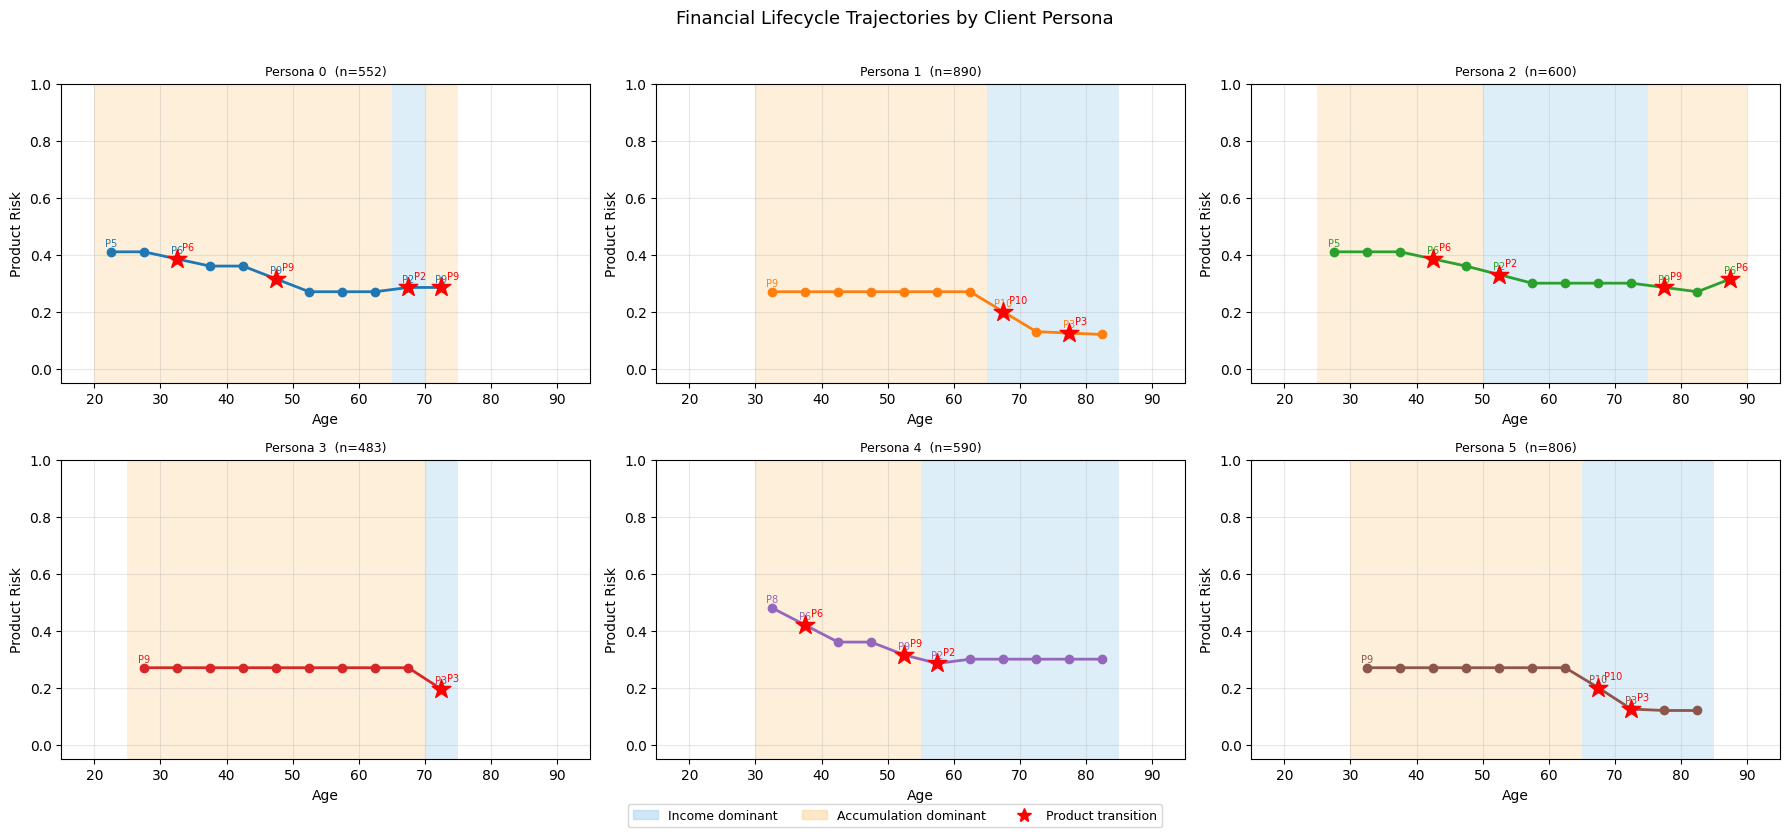

In [11]:
NEED_COLORS = {'Income': '#AED6F1', 'Accumulation': '#FAD7A0'}
LINE_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
ncols = min(best_k, 3)
nrows = (best_k + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).ravel()

for c in range(best_k):
    ax = axes[c]

    # Drop P0 (no-match) waypoints — catalog gap, not a real product
    traj_raw = (
        traj_df[(traj_df['cluster'] == c) & (traj_df['product_id'] != 0)]
        .sort_values('age_mid')
        .reset_index(drop=True)
    )
    if traj_raw.empty:
        ax.set_visible(False)
        continue

    # Smooth product_risk (window=2, centred) to reduce band-level variance noise
    traj = traj_raw.copy()
    traj['risk_smooth'] = (
        traj['product_risk']
        .rolling(window=2, center=True, min_periods=1)
        .mean()
    )

    col = LINE_COLORS[c % len(LINE_COLORS)]

    # Background shading per dominant need
    half_step = 2.5
    for _, row in traj.iterrows():
        ax.axvspan(
            row['age_mid'] - half_step,
            row['age_mid'] + half_step,
            color=NEED_COLORS[row['need']],
            alpha=0.4,
            lw=0,
        )

    # Trajectory line (smoothed)
    ax.plot(traj['age_mid'], traj['risk_smooth'], 'o-', color=col, lw=2, zorder=3)

    # Transition markers — guard against empty trans_df, exclude No-match arrivals
    if not trans_df.empty:
        valid_ages = set(traj['age_mid'])
        c_trans = trans_df[
            (trans_df['cluster'] == c) &
            (trans_df['age'].isin(valid_ages)) &
            (~trans_df['to_prod'].str.contains('No match'))
        ]
        for _, tr in c_trans.iterrows():
            age_t  = tr['age']
            risk_t = traj.loc[traj['age_mid'] == age_t, 'risk_smooth'].values
            if len(risk_t):
                ax.scatter(age_t, risk_t[0], marker='*', s=200, color='red', zorder=5)
                ax.annotate(
                    tr['to_prod'].split('(')[0].strip(),
                    xy=(age_t, risk_t[0]),
                    xytext=(4, 6), textcoords='offset points',
                    fontsize=7, color='red',
                )

    # Product label at first occurrence of each product
    prev_prod = None
    for _, row in traj.iterrows():
        if row['product_id'] != prev_prod:
            ax.text(
                row['age_mid'], row['risk_smooth'] + 0.02,
                f"P{int(row['product_id'])}",
                fontsize=7, ha='center', color=col,
            )
            prev_prod = row['product_id']

    name      = PERSONA_NAMES.get(c, f'Persona {c}')
    n_clients = (cluster_labels == c).sum()
    ax.set_title(f'{name}  (n={n_clients})', fontsize=9)
    ax.set_xlabel('Age')
    ax.set_ylabel('Product Risk')
    ax.set_xlim(15, 95)
    ax.set_ylim(-0.05, 1.0)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(best_k, len(axes)):
    axes[i].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color=NEED_COLORS['Income'],       alpha=0.6, label='Income dominant'),
    mpatches.Patch(color=NEED_COLORS['Accumulation'], alpha=0.6, label='Accumulation dominant'),
    plt.Line2D([0],[0], marker='*', color='red', lw=0, markersize=10, label='Product transition'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Financial Lifecycle Trajectories by Client Persona', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


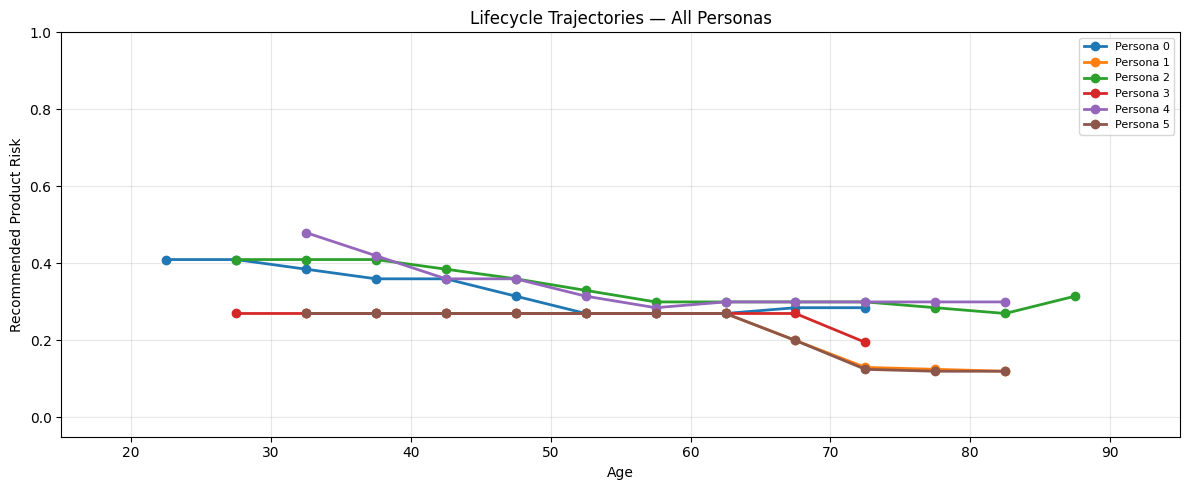

In [12]:
# ── All clusters on a single chart (overview) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for c in range(best_k):
    traj_raw = (
        traj_df[(traj_df['cluster'] == c) & (traj_df['product_id'] != 0)]
        .sort_values('age_mid')
    )
    if traj_raw.empty:
        continue
    traj = traj_raw.copy()
    traj['risk_smooth'] = (
        traj['product_risk']
        .rolling(window=2, center=True, min_periods=1)
        .mean()
    )
    col  = LINE_COLORS[c % len(LINE_COLORS)]
    name = PERSONA_NAMES.get(c, f'Persona {c}')
    ax.plot(traj['age_mid'], traj['risk_smooth'], 'o-',
            color=col, lw=2, label=name)

ax.set_xlabel('Age')
ax.set_ylabel('Recommended Product Risk')
ax.set_title('Lifecycle Trajectories — All Personas')
ax.set_xlim(15, 95)
ax.set_ylim(-0.05, 1.0)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ── Lifecycle summary table ───────────────────────────────────────────────────
print('LIFECYCLE SUMMARY')
print('=' * 70)

for c in range(best_k):
    traj = traj_df[traj_df['cluster'] == c].sort_values('age_mid').reset_index(drop=True)
    n    = (cluster_labels == c).sum()
    c_tr = trans_df[trans_df['cluster'] == c] if len(trans_df) else pd.DataFrame()

    print(f'\n{PERSONA_NAMES.get(c, f"Persona {c}").upper()}  ({n} clients)')

    # Group consecutive waypoints with same product
    segments = []
    for i, row in traj.iterrows():
        if not segments or segments[-1]['product_id'] != row['product_id']:
            segments.append({
                'start_age':  row['age_mid'],
                'end_age':    row['age_mid'],
                'need':       row['need'],
                'product_id': row['product_id'],
                'prod_risk':  row['product_risk'],
            })
        else:
            segments[-1]['end_age'] = row['age_mid']

    for seg in segments:
        age_range = f"{seg['start_age']:.0f}\u2013{seg['end_age']:.0f}"
        label = f"P{seg['product_id']}" if seg['product_id'] > 0 else 'no match'
        print(f"  Age {age_range:8s}  {seg['need']:14s}  "
              f"{label:10s}  (risk {seg['prod_risk']:.2f})")

    print(f'  Transitions: {len(c_tr)}')

LIFECYCLE SUMMARY

PERSONA 0  (552 clients)
  Age 22–28     Accumulation    P5          (risk 0.41)
  Age 32–42     Accumulation    P6          (risk 0.36)
  Age 48–62     Accumulation    P9          (risk 0.27)
  Age 68–68     Income          P2          (risk 0.30)
  Age 72–72     Accumulation    P9          (risk 0.27)
  Transitions: 4

PERSONA 1  (890 clients)
  Age 32–62     Accumulation    P9          (risk 0.27)
  Age 68–72     Income          P10         (risk 0.13)
  Age 78–82     Income          P3          (risk 0.12)
  Transitions: 2

PERSONA 2  (600 clients)
  Age 28–38     Accumulation    P5          (risk 0.41)
  Age 42–48     Accumulation    P6          (risk 0.36)
  Age 52–72     Income          P2          (risk 0.30)
  Age 78–82     Accumulation    P9          (risk 0.27)
  Age 88–88     Accumulation    P6          (risk 0.36)
  Transitions: 4

PERSONA 3  (483 clients)
  Age 28–68     Accumulation    P9          (risk 0.27)
  Age 72–72     Income          P3         

## Conclusions & business implications

The lifecycle trajectory analysis extends point-in-time recommendations to a longitudinal view,
quantifying *when* product transitions occur and *why* they differ across client personas.

**Structural finding**: the Accumulation → Income transition is not uniform across clients.
It occurs earlier for high-wealth, high-education personas and later for asset-rich,
income-constrained profiles — consistent with lifecycle theory (Merton 1969).

**Catalog gap finding**: a share of clients cannot be matched to any product even
at t=0. These clients are excluded from the trajectory analysis — their existence
quantifies an unmet need in the current product range, with direct implications
for product development.

**Limitations**:
1. *Generational stationarity* — a 60-year-old today grew up in a different macro
   environment than a 30-year-old will. Cohort effects are absorbed as lifecycle signal.
2. *Cluster stability* — behavioral profile (risk, education) is assumed stable
   within a cluster as age increases. In reality, risk appetite may genuinely evolve.
3. *Model extrapolation* — XGBoost was trained on real clients;
   applying it to synthetic waypoints is an extrapolation, not a direct prediction.